In [115]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv


In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

In [117]:
df = pd.read_csv('/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv')
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [118]:
df.shape

(100000, 32)

In [119]:
df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

In [120]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [121]:
df.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

# *EDA*

**Target Distribution**

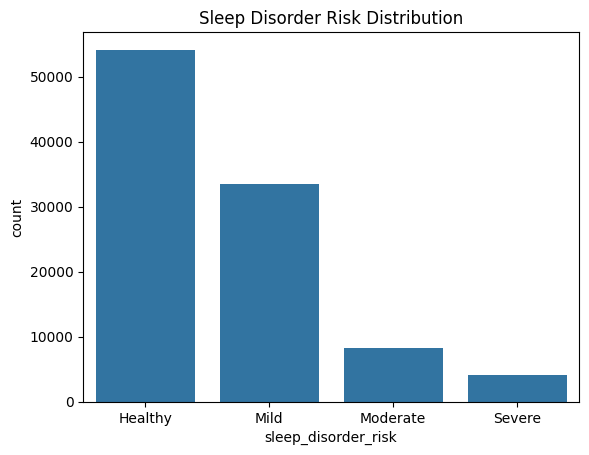

In [122]:
sns.countplot(x='sleep_disorder_risk', data=df, order=['Healthy','Mild','Moderate','Severe'])
plt.title('Sleep Disorder Risk Distribution')
plt.show()

** Gender vs sleep disorder risk**

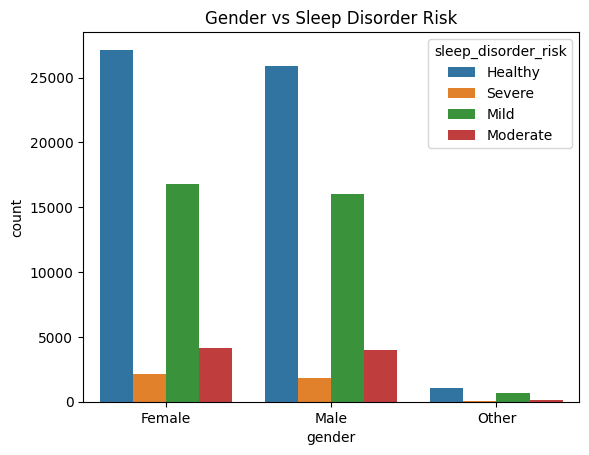

In [123]:
sns.countplot(x='gender', hue='sleep_disorder_risk', data=df)
plt.title('Gender vs Sleep Disorder Risk')
plt.show()

**Chronotype impact**

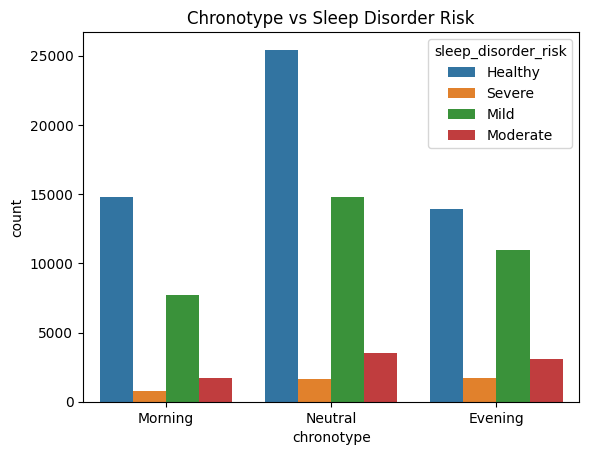

In [124]:
sns.countplot(x='chronotype', hue='sleep_disorder_risk', data=df)
plt.title('Chronotype vs Sleep Disorder Risk')
plt.show()

**Age distribution**

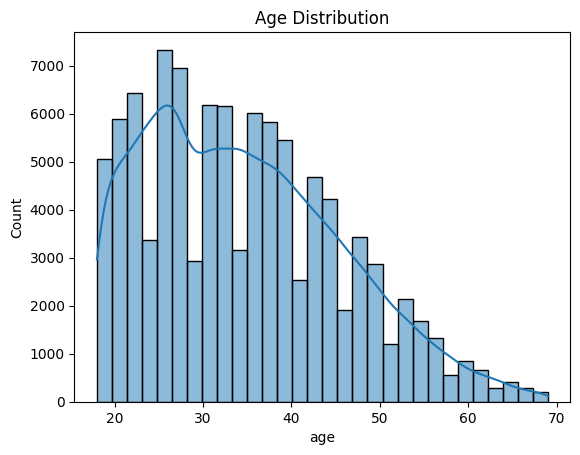

In [125]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

** Correlation heatmap**

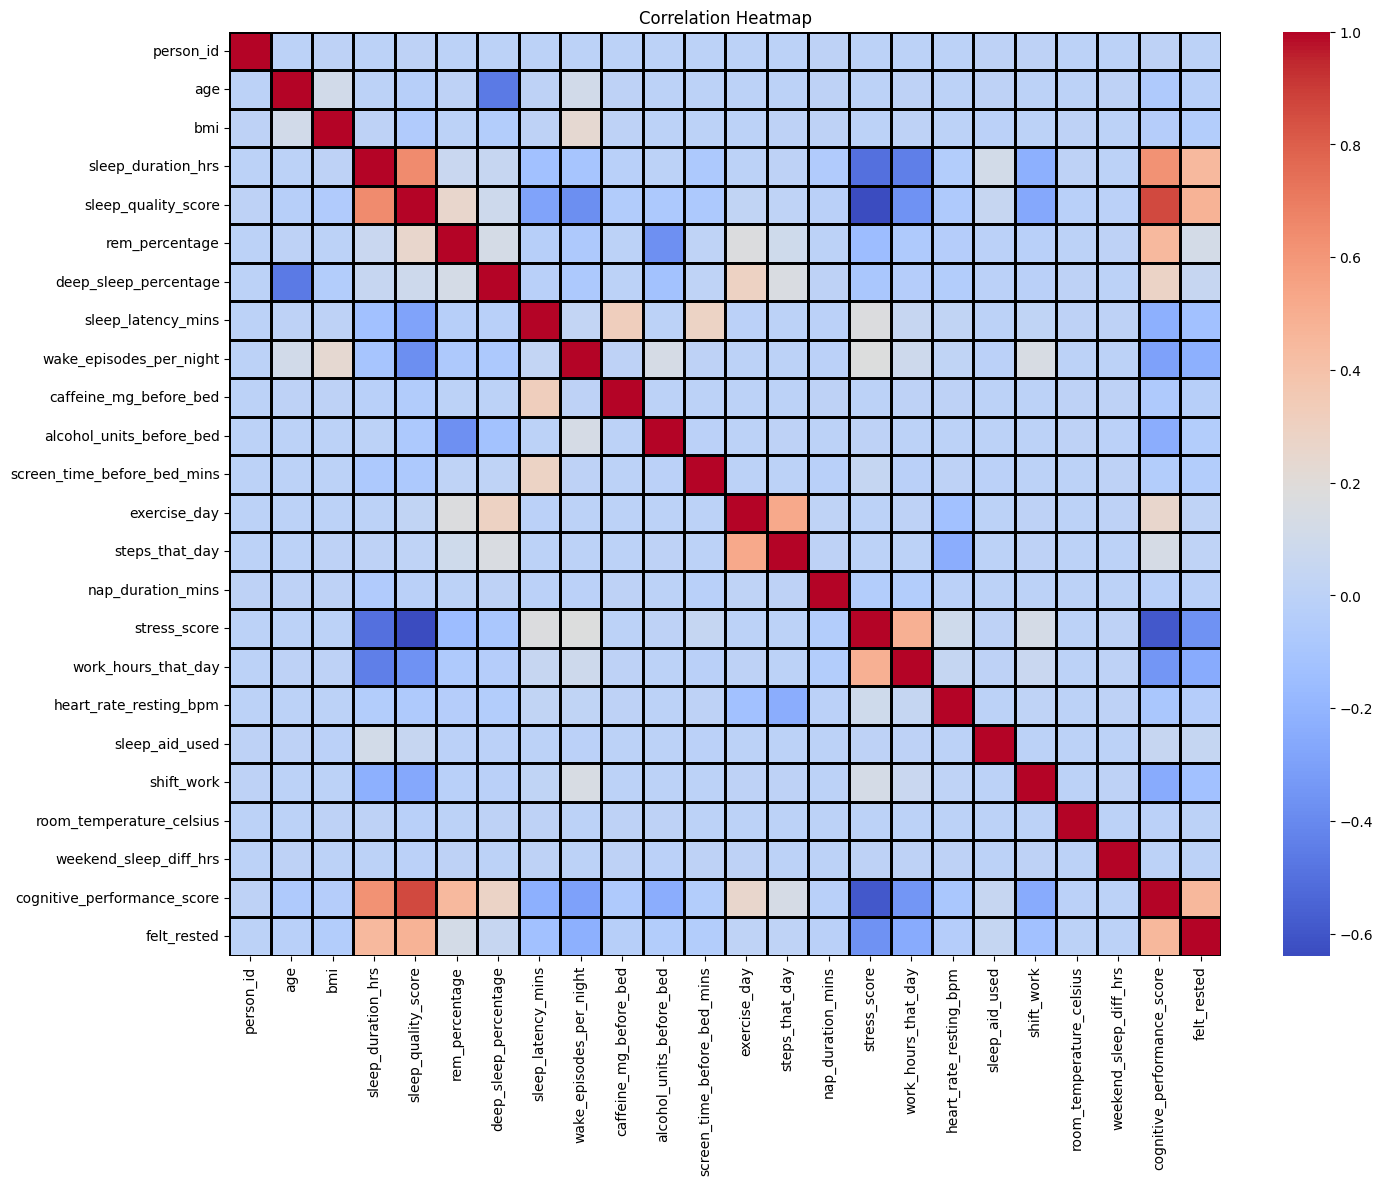

In [126]:
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', linewidths=1, linecolor='black')
plt.title('Correlation Heatmap')
plt.show()

# *Data Cleaning*

In [127]:
df_model = df.copy()

In [128]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['sleep_disorder_risk'] = le.fit_transform(df_model['sleep_disorder_risk'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Healthy': np.int64(0), 'Mild': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}


One-Hot Encoding

In [129]:
df_model = pd.get_dummies(
    df_model,
    columns=['gender', 'chronotype', 'mental_health_condition',
             'season', 'day_type', 'occupation', 'country'],
    drop_first=True
)

df_model.drop(columns=['person_id'], inplace=True)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 60 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   bmi                                 100000 non-null  float64
 2   sleep_duration_hrs                  100000 non-null  float64
 3   sleep_quality_score                 100000 non-null  float64
 4   rem_percentage                      100000 non-null  float64
 5   deep_sleep_percentage               100000 non-null  float64
 6   sleep_latency_mins                  100000 non-null  int64  
 7   wake_episodes_per_night             100000 non-null  int64  
 8   caffeine_mg_before_bed              100000 non-null  int64  
 9   alcohol_units_before_bed            100000 non-null  float64
 10  screen_time_before_bed_mins         100000 non-null  int64  
 11  exercise_day               

In [130]:
X = df_model.drop(columns=['sleep_disorder_risk'])
y = df_model['sleep_disorder_risk']

print('Shape of X:', X.shape)
print('Class distribution:\n', y.value_counts())

Shape of X: (100000, 59)
Class distribution:
 sleep_disorder_risk
0    54156
1    33479
2     8299
3     4066
Name: count, dtype: int64


# *Train-Test Split*

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# *Random Forest (Baseline Model)*

In [132]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    class_weight={0: 1, 1: 2, 2: 4, 3: 5},  # manually boost Moderate & Severe
    max_features='sqrt',
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 2, 2: 4, 3: 5}, max_depth=20,
                       n_estimators=200, random_state=42)

In [133]:
y_pred_rf = rf_model.predict(X_test)

# *Accuracy & classification report*

In [134]:
from sklearn.metrics import accuracy_score, classification_report

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy: 0.8908

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96     10831
        Mild       0.83      0.91      0.87      6696
    Moderate       0.68      0.49      0.57      1660
      Severe       0.85      0.69      0.76       813

    accuracy                           0.89     20000
   macro avg       0.83      0.76      0.79     20000
weighted avg       0.89      0.89      0.89     20000



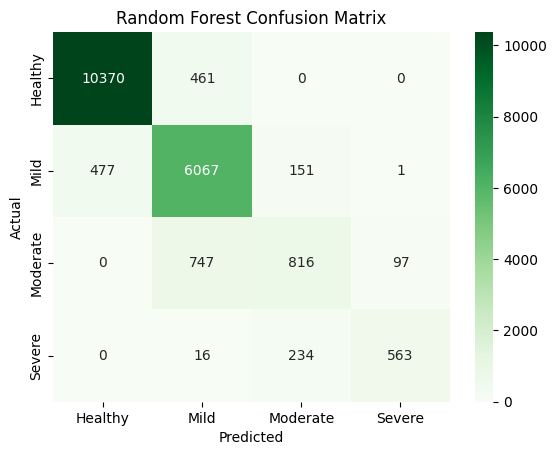

In [135]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [136]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

sleep_quality_score                0.112724
cognitive_performance_score        0.111113
sleep_duration_hrs                 0.097807
bmi                                0.082212
mental_health_condition_Healthy    0.077828
stress_score                       0.056530
sleep_latency_mins                 0.053738
wake_episodes_per_night            0.046494
rem_percentage                     0.026478
mental_health_condition_Both       0.023378
dtype: float64

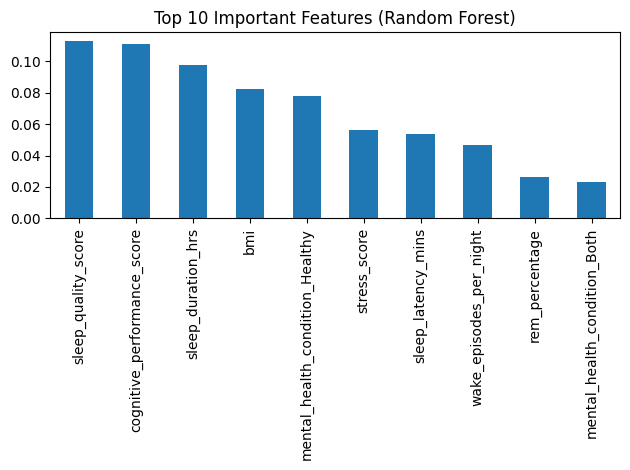

In [137]:
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Important Features (Random Forest)')
plt.tight_layout()
plt.show()